In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# List of stock tickers
%run "../helpers/data_manipulator.py"

stocks = sp_500 + nasdaq_100
# Remove duplicates
tickers = list(dict.fromkeys(stocks))

# Download historical data for the past year
data = yf.download(tickers, start="2023-01-01", end="2024-12-31")['Close']

# Calculate daily returns
daily_returns = data.pct_change()

# Calculate 20-day rolling volatility
volatility = daily_returns.rolling(window=20).std().dropna()
mean = daily_returns.rolling(window=20).mean().dropna()

# Get the latest volatility values for clustering
last_200_volatility = volatility.tail(200)
last_200_mean = mean.tail(200)

print(daily_returns)


# Combine features into a single DataFrame where each row represents a stock
features = pd.concat([last_200_mean.T, last_200_volatility.T], axis=1)

# Rename columns to distinguish between mean and std series
features.columns = [f'Mean_{i}' for i in range(200)] + [f'StdDev_{i}' for i in range(200)]



*********************100%***********************]  311 of 311 completed

Ticker             A      AAPL      ABBV      ABNB       ABT       ACN  \
Date                                                                     
2023-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2023-01-04  0.010864  0.010314  0.008068  0.044994  0.014875 -0.003404   
2023-01-05  0.002901 -0.010605 -0.001222 -0.011384 -0.003687 -0.023613   
2023-01-06 -0.029189  0.036794  0.018717  0.009235  0.013809  0.023690   
2023-01-09 -0.001354  0.004089 -0.029361  0.008134 -0.001603  0.016864   
...              ...       ...       ...       ...       ...       ...   
2024-12-23  0.000669  0.003065  0.016004  0.002310  0.000700 -0.020744   
2024-12-24  0.011144  0.011478  0.009025  0.003494  0.003937  0.007972   
2024-12-26 -0.001984  0.003176 -0.004444  0.002445  0.004444 -0.003318   
2024-12-27 -0.002135 -0.013242 -0.006641 -0.014300 -0.002429 -0.011791   
2024-12-30 -0.008263 -0.013263 -0.010168 -0.011808 -0.019045 -0.010360   

Ticker          ADBE       ADI       

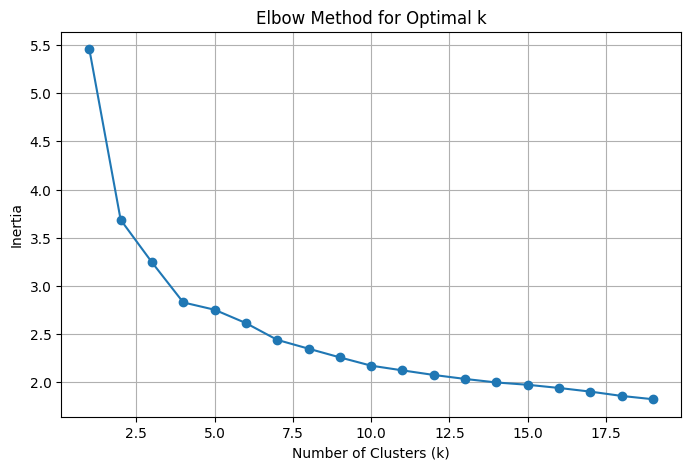

        Stock  Cluster
Ticker                
A           A        0
AAPL     AAPL        0
ABBV     ABBV        0
ABT       ABT        0
ACN       ACN        0
ADM       ADM        0
ADP       ADP        0
AEP       AEP        0
AFL       AFL        0
AIG       AIG        0
AJG       AJG        0
AME       AME        0
AMGN     AMGN        0
AMP       AMP        0
AMT       AMT        0
ANSS     ANSS        0
AON       AON        0
APD       APD        0
ARE       ARE        0
AVB       AVB        0
AXP       AXP        0
AZN       AZN        0
AZO       AZO        0
BAC       BAC        0
BDX       BDX        0
BIIB     BIIB        0
BK         BK        0
BKNG     BKNG        0
BLK       BLK        0
BRK-B   BRK-B        0
BSX       BSX        0
CAG       CAG        0
CB         CB        0
CCEP     CCEP        0
CCI       CCI        0
CI         CI        0
CL         CL        0
CMCSA   CMCSA        0
CME       CME        0
CMI       CMI        0
COP       COP        0
COR       C

In [3]:

# Determine the optimal number of clusters using the Elbow Method
inertia = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 20), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

# Perform k-means clustering with the optimal k (e.g., from the elbow method)
optimal_k = 5  # Adjust based on the Elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(features)

features['Cluster'] = kmeans.labels_

# Assign cluster labels to stocks
cluster_labels = pd.DataFrame({
    'Stock': features.index,
    'Cluster': features['Cluster']
})

pd.set_option('display.max_rows', None)
print(cluster_labels.sort_values(by=["Cluster", "Stock"]))

cluster_labels.to_csv("../stock-clusters.csv", index=False)